# ---------- IMPORTING LIBRARIES ----------

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# LOADING DATASET
df = pd.read_csv("C:\\Users\\İlyas\\OneDrive\\Belgeler\\veri setleri ve vs code çalışmaları\\netflix_titles.csv")

# ---------- BASIC DATA EXPLORATION ----------

In [6]:
print("First 5 rows of the dataset:")
print('---------------------------------------')
df.head()

First 5 rows of the dataset:
---------------------------------------


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
print("\nDataset Information:")
print('-------------------------------------')
df.info()


Dataset Information:
-------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
print("\nMissing Values:")
print("------------------------")
print(df.isnull().sum())


Missing Values:
------------------------
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


# ------------- CATEGORICAL AND VISUAL REVIEW -----------------

In [11]:
type_counts = df['type'].value_counts()

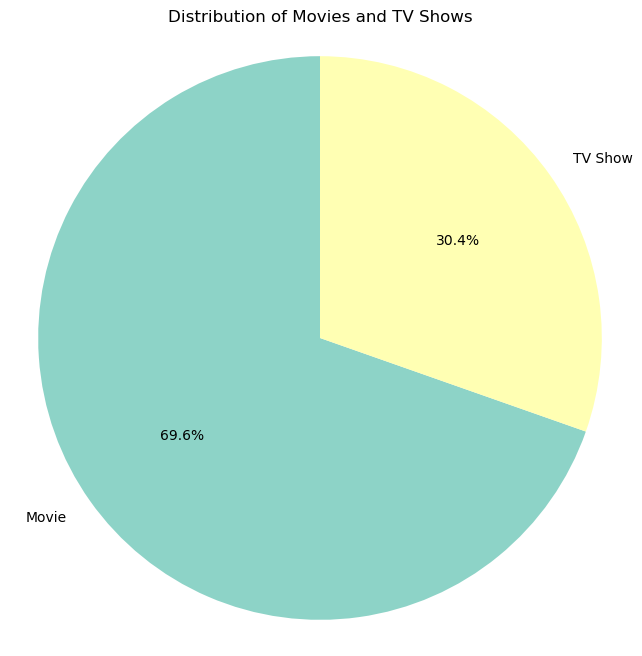

In [12]:
plt.figure(figsize=(8, 8))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Set3", n_colors=len(type_counts))
)
plt.title("Distribution of Movies and TV Shows")
plt.axis("equal")  # Daireyi korur
plt.show()

In [13]:
df = df.dropna(subset=['date_added'])

In [14]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [15]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [16]:
df['year_added'] = df['date_added'].dt.year

In [17]:
df = df[df['year_added'] != 0]

In [18]:
df['year_added'] = df['year_added'].astype('Int64')

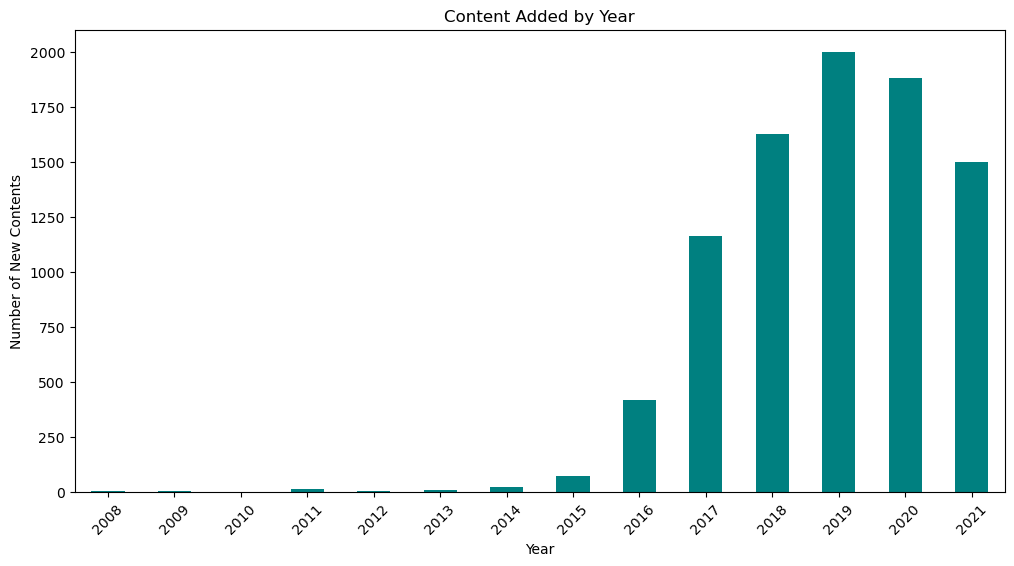

In [ ]:
# Yıllara göre içerik ekleme sayısını hesaplıyoruz
yearly_data = df.groupby('year_added').size()

#  bar chart ile görselleştiriyoruz
plt.figure(figsize=(12, 6))
yearly_data.plot(kind='bar', color='teal')
plt.title('Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of New Contents')
plt.xticks(rotation=45)
plt.show()

C:\Users\İlyas\AppData\Local\Temp\ipykernel_17296\1475007513.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette="Set2")


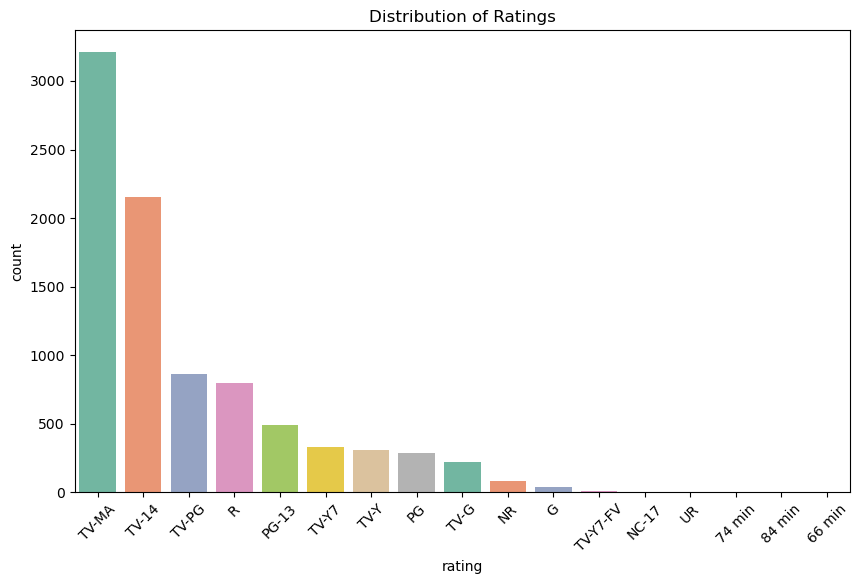

In [20]:
# Rating dağılımını görselleştirmek için countplot kullanıyoruz
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette="Set2")
plt.title('Distribution of Ratings')
plt.xticks(rotation=45)
plt.show()

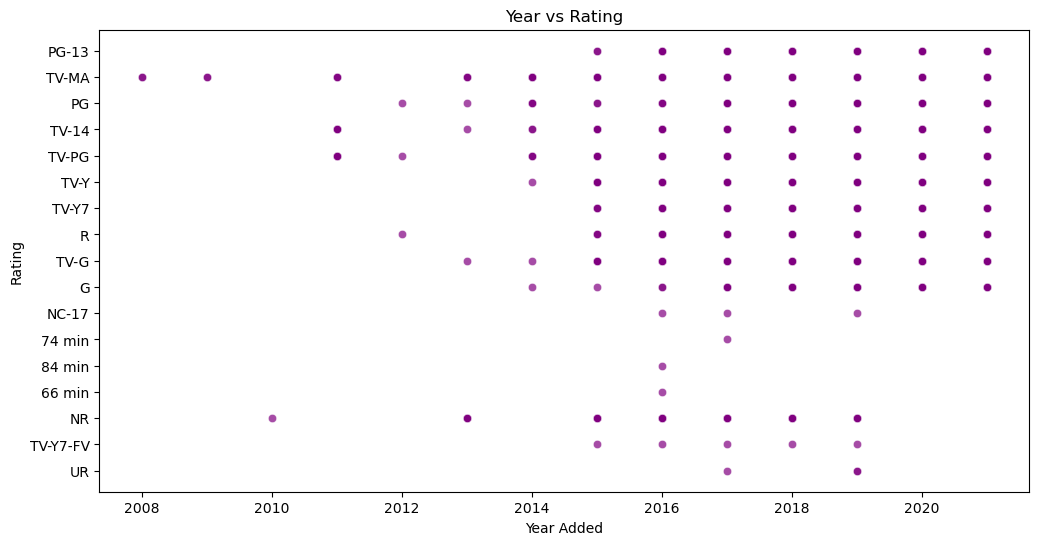

In [ ]:

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='year_added', y='rating', alpha=0.7, color='purple')
plt.title('Year vs Rating')
plt.xlabel('Year Added')
plt.ylabel('Rating')
plt.show()

C:\Users\İlyas\AppData\Local\Temp\ipykernel_17296\2260760368.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year_added', y='rating', palette='muted')


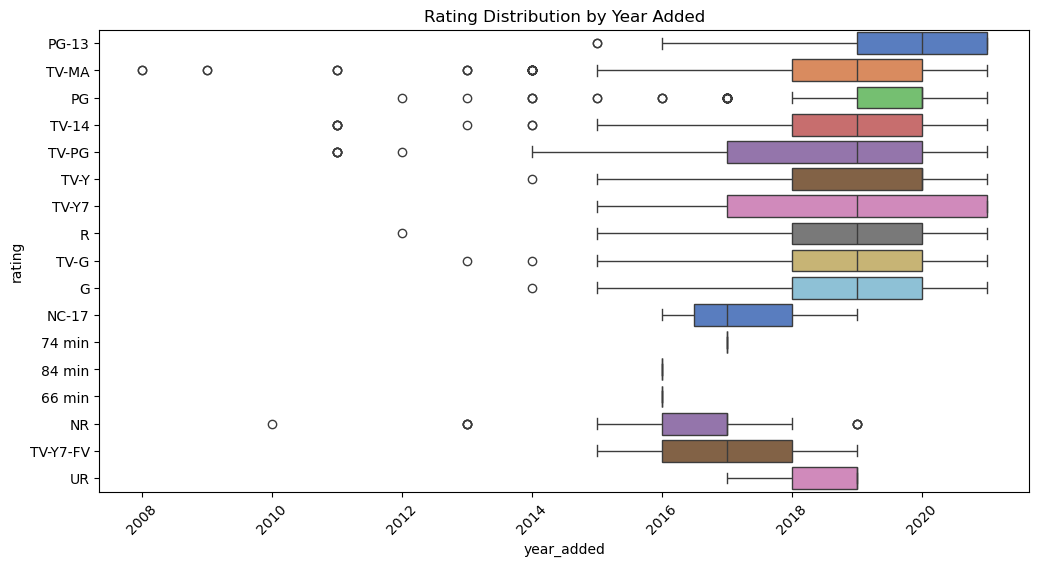

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='year_added', y='rating', palette='muted')
plt.title('Rating Distribution by Year Added')
plt.xticks(rotation=45)
plt.show()

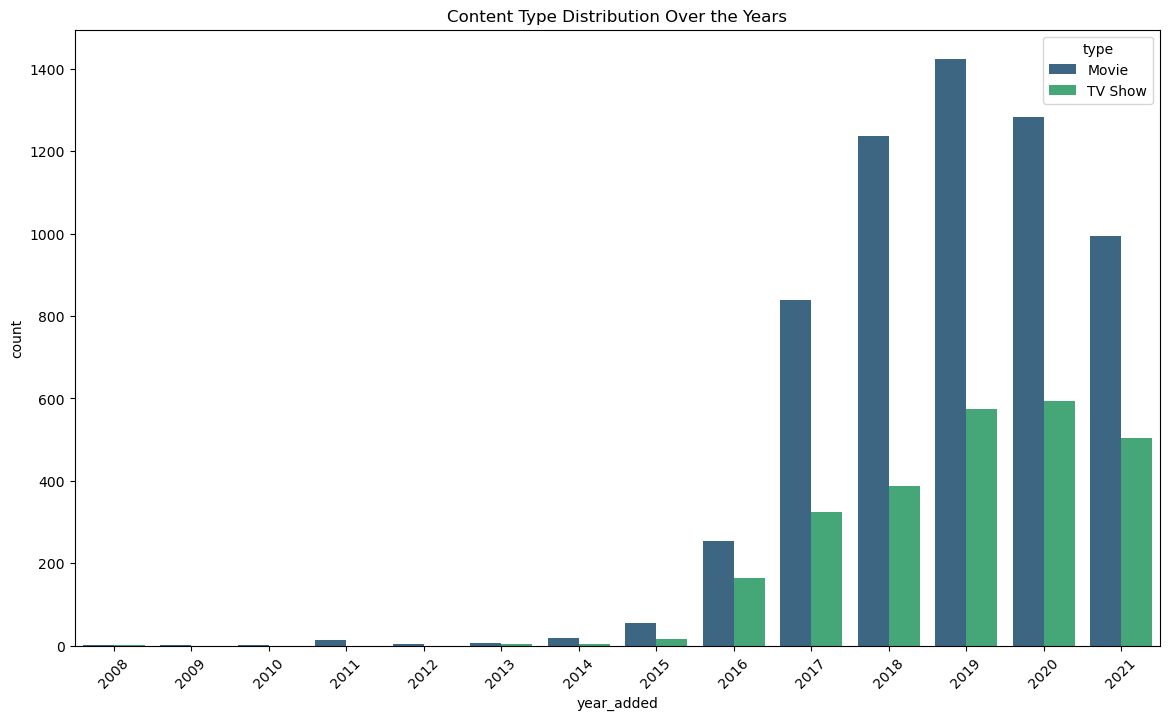

In [ ]:
nı görselleştiriyoruz
plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='year_added', hue='type', palette='viridis')
plt.title('Content Type Distribution Over the Years')
plt.xticks(rotation=45)
plt.show()

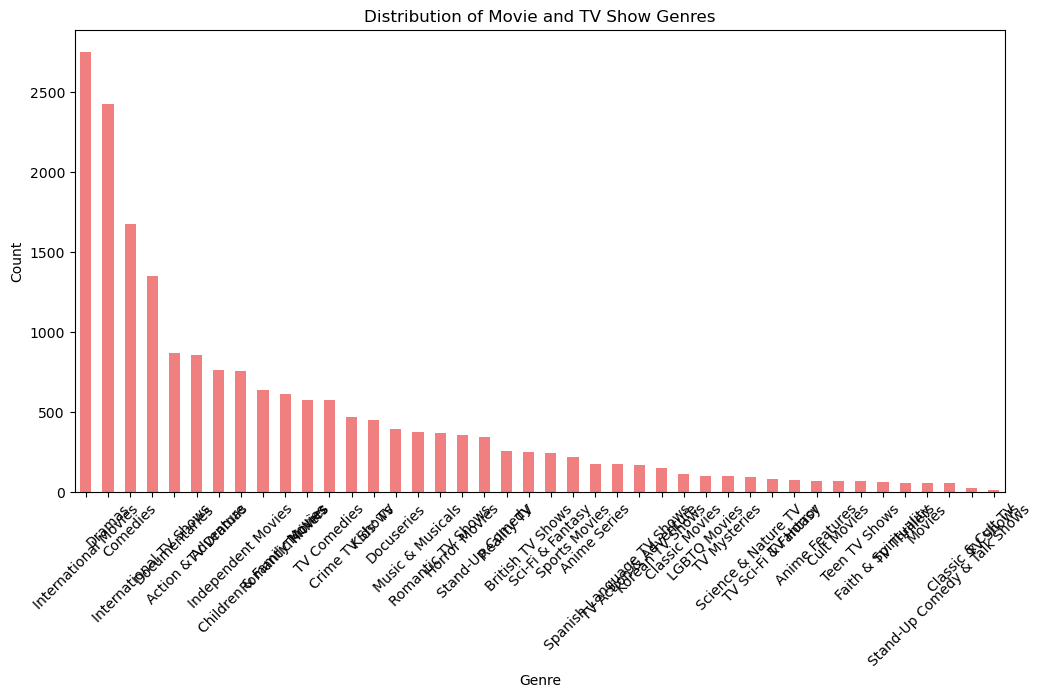

In [24]:
# 'listed_in' sütunundaki türleri ayıralım
genres = df['listed_in'].str.split(', ', expand=True).stack()

# Türlerin sayısal dağılımını hesapla
genre_counts = genres.value_counts()

# Görselleştirme
plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='lightcoral')
plt.title('Distribution of Movie and TV Show Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

<Figure size 1500x900 with 0 Axes>

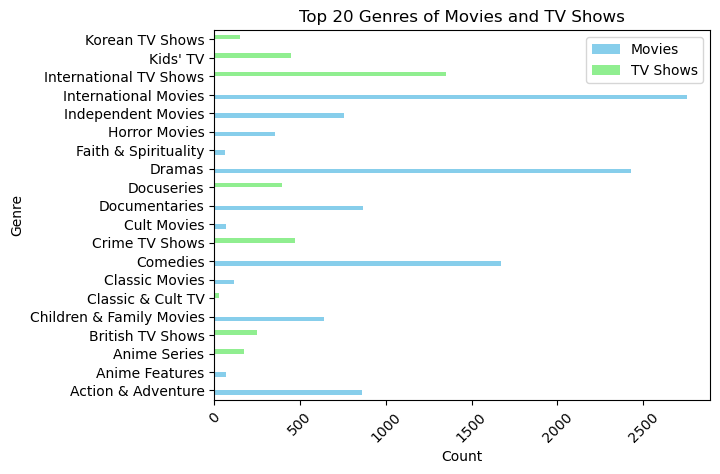

In [32]:
# Film ve dizi türlerini ayıralım
movies_df = df[df['type'] == 'Movie']
tv_shows_df = df[df['type'] == 'TV Show']

# Film ve dizi türlerini 'listed_in' sütunundan alalım
movie_genres = movies_df['listed_in'].str.split(', ').explode().str.strip()
tv_genres = tv_shows_df['listed_in'].str.split(', ').explode().str.strip()

# Türlerin sayısal dağılımını hesaplayalım
movie_genre_counts = movie_genres.value_counts()
tv_genre_counts = tv_genres.value_counts()

# Türlerin karşılaştırılması için birleştirelim
combined_genre_counts = pd.DataFrame({
    'Movies': movie_genre_counts,
    'TV Shows': tv_genre_counts
}).fillna(0)

# Görselleştirme: Film türleri mavi, Dizi türleri yeşil olacak
plt.figure(figsize=(15, 9))

# Filmler için mavi, diziler için yeşil renk
combined_genre_counts.head(20).plot(kind='barh', stacked=False, color=['skyblue', 'lightgreen'])

# Başlık ve etiketler
plt.title('Top 20 Genres of Movies and TV Shows')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.xticks(rotation=45)
plt.show()


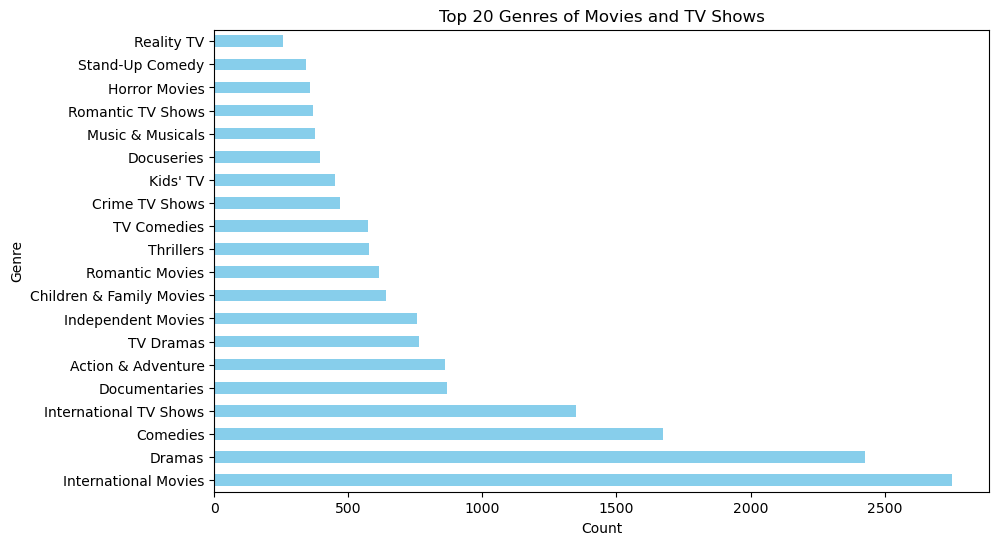

In [37]:
genres = df['listed_in'].str.split(', ', expand=True).stack()
genre_counts = genres.value_counts()

plt.figure(figsize=(10, 6))
genre_counts.head(20).plot(kind='barh', color='skyblue')   
plt.title('Top 20 Genres of Movies and TV Shows')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()